In [1]:
from training.config import ROOT
from data import build_mnist_splits
import torch
from torch.utils.data import DataLoader

data_dir = ROOT / "data"
# Basic MNIST: return float tensor in [0,1], shape (1,28,28)
mnist, _, _ = build_mnist_splits(data_dir=data_dir)

loader = DataLoader(mnist, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

/home/wiss/akid/miniconda3/envs/comp_vis/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
from data import MovingMNIST

moving_ds = MovingMNIST(mnist, T=20, canvas=64, vmin=-3, vmax=3)
moving_loader = DataLoader(moving_ds, batch_size=16, shuffle=True, num_workers=2) 
x, y, _, _ = next(iter(moving_loader))
print(x.shape, y.shape) # (B,T,1,64,64), (B,)


torch.Size([16, 20, 1, 64, 64]) torch.Size([16])


In [3]:
import numpy as np
import random
import os
import cv2
import torch.nn.functional as F


def upsample_video(x, scale=4, size=None, mode="nearest"):
    if x.dim() == 4:
        kwargs = {}
        if mode in ("bilinear", "bicubic", "trilinear"):
            kwargs["align_corners"] = False
        return F.interpolate(x, size=size, scale_factor=None if size else scale, mode=mode, **kwargs)

    if x.dim() == 5:
        B, T, C, H, W = x.shape
        y = x.reshape(B * T, C, H, W)
        kwargs = {}
        if mode in ("bilinear", "bicubic", "trilinear"):
            kwargs["align_corners"] = False
        y = F.interpolate(y, size=size, scale_factor=None if size else scale, mode=mode, **kwargs)
        H2, W2 = y.shape[-2:]
        return y.reshape(B, T, C, H2, W2)

    raise ValueError("Expected [T,1,H,W] or [B,T,1,H,W]")


def save_video_tensor(video, filename="moving_sample.mp4", fps=10):
    """
    video: (T,1,H,W) float in [0,1]
    """
    T, C, H, W = video.shape
    assert C == 1

    # convert to uint8
    video_np = (video.squeeze(1).cpu().numpy() * 255).astype(np.uint8)  # (T,H,W)

    # OpenCV expects BGR 3-channel
    video_np = np.stack([video_np] * 3, axis=-1)  # (T,H,W,3)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(filename, fourcc, fps, (W, H))

    for t in range(T):
        writer.write(video_np[t])

    writer.release()
    print(f"Saved video to: {os.path.abspath(filename)}")


outputs_dir = ROOT / "outputs"
idx = random.randint(0, len(moving_ds) - 1)
video, label, _, _ = moving_ds[idx]  # video: (T,1,H,W)
print("Label:", label)

scale = 8
upsampled = upsample_video(video, scale=scale, mode="nearest")
save_video_tensor(upsampled, f"{outputs_dir}/moving_mnist_clean.mp4", fps=8)


Label: 0
Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_clean.mp4


Saved mask figure to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/mask_bernoulli.png


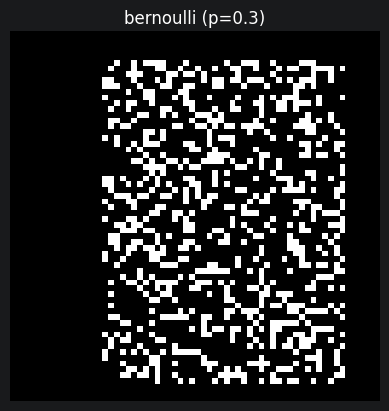

Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_occ_bernoulli.mp4
Saved mask figure to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/mask_cgol.png


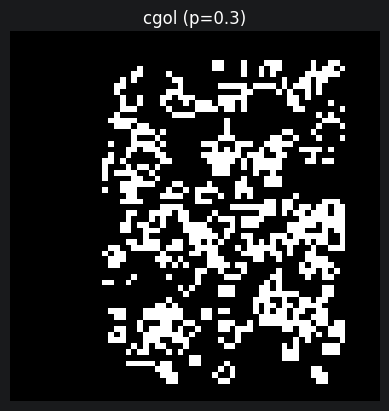

Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_occ_cgol.mp4
Saved mask figure to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/mask_triangular.png


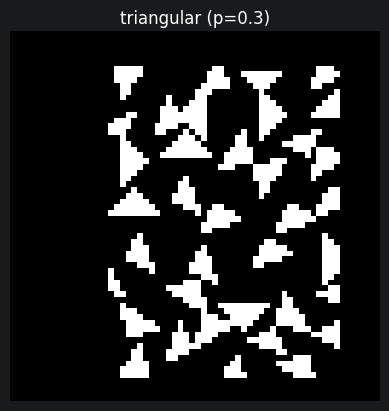

Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_occ_triangular.mp4
Saved mask figure to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/mask_perlin.png


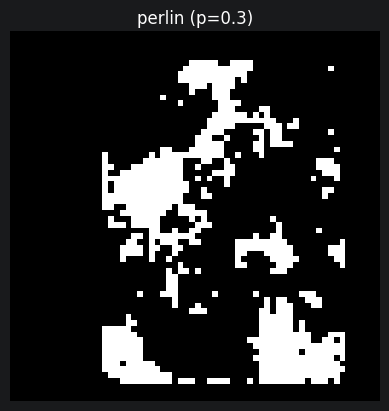

Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_occ_perlin.mp4
Saved mask figure to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/mask_branches.png


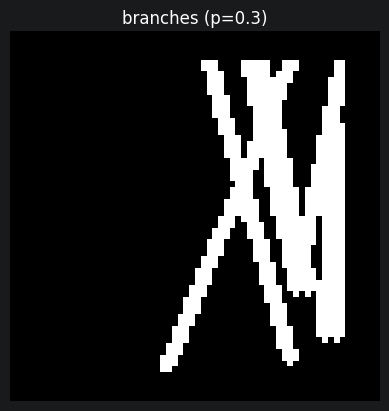

Saved video to: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/moving_mnist_occ_branches.mp4
[OK] Wrote stitched image: /storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/combined_2x2.png


PosixPath('/storage/user/akid/git_projects/MovingMNIST-OcclusionBench/outputs/combined_2x2.png')

In [4]:
from matplotlib import pyplot as plt
from occluders import Occ, apply_mask_to_video
from PIL import Image
from pathlib import Path


def show_mask(mask, p, occ, b=0, ax=None, save_path=None, dpi=150, show=True):
    """
    mask: [T,1,H,W] or [B,T,1,H,W] float/bool
    save_path: if provided, saves the figure (e.g. "mask.png")
    dpi: save resolution
    show: whether to call plt.show() (set False when saving many)
    """
    if mask.dim() == 5:
        m = mask[b, 0, 0].detach().cpu().numpy()
        title = f"{occ.name.lower()} (p={p})"
    else:
        m = mask[0, 0].detach().cpu().numpy()
        title = f"{occ.name.lower()} (p={p})"

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots()
        created_fig = True
    else:
        fig = ax.figure

    ax.imshow(m, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", pad_inches=0, dpi=dpi)
        print(f"Saved mask figure to: {save_path.resolve()}")

    if show:
        plt.show()
    elif created_fig:
        plt.close(fig)


def stitch_pngs_2x2(png_paths, out_path="combined.png", *, bg="white", pad=20):
    """
    png_paths: list/tuple of 4 paths in order:
      [top-left, top-right, bottom-left, bottom-right]
    Produces one stitched PNG (2x2) with padding.
    """
    if len(png_paths) != 4:
        raise ValueError("Provide exactly 4 PNG paths (TL, TR, BL, BR).")

    imgs = [Image.open(str(p)).convert("RGBA") for p in png_paths]

    # Normalize sizes (use max width/height among images)
    w = max(im.width for im in imgs)
    h = max(im.height for im in imgs)

    def pad_to(im, w, h):
        canvas = Image.new("RGBA", (w, h), bg)
        x = (w - im.width) // 2
        y = (h - im.height) // 2
        canvas.paste(im, (x, y), im)
        return canvas

    imgs = [pad_to(im, w, h) for im in imgs]

    out_w = 2 * w + 3 * pad
    out_h = 2 * h + 3 * pad
    out = Image.new("RGBA", (out_w, out_h), bg)

    # positions: TL, TR, BL, BR
    positions = [
        (pad, pad),
        (2 * pad + w, pad),
        (pad, 2 * pad + h),
        (2 * pad + w, 2 * pad + h),
    ]
    for im, (x, y) in zip(imgs, positions):
        out.paste(im, (x, y), im)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out = out.convert("RGB")  # drop alpha
    out.save(str(out_path))
    print(f"[OK] Wrote stitched image: {out_path.resolve()}")
    return out_path


p = 0.3  # dense occlusion
# occlude same sample with different occlusion models (Bernoulli, Perlin), upsample and save
save_paths = []
for occ in Occ:
    occ_name = occ.name.lower()
    masked, mask = apply_mask_to_video(video, occ, p)
    save_paths.append(f"{outputs_dir}/mask_{occ_name}.png")
    show_mask(mask, p, occ, save_path=save_paths[-1])  # display + save
    upsampled = upsample_video(masked, scale=scale, mode="nearest")
    save_video_tensor(upsampled, f"{outputs_dir}/moving_mnist_occ_{occ_name}.mp4", fps=8)

stitch_pngs_2x2(save_paths[:4], out_path=f"{outputs_dir}/combined_2x2.png", pad=25)